In [1]:
from google.colab import files
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# split_train.parquet, split_val.parquet, split_test.parquet
uploaded = files.upload()

# Load splits
df_train = pd.read_parquet("split_train.parquet")
df_val   = pd.read_parquet("split_val.parquet")
df_test  = pd.read_parquet("split_test.parquet")

SPLIT_DIR = ""

KEYWORDS = df_train["keyword"].unique()
CITIES   = df_train["city"].unique()

print(f"Train: {len(df_train)} rows, {df_train['month'].nunique()} months")
print(f"Val:   {len(df_val)} rows, {df_val['month'].nunique()} months")
print(f"Test:  {len(df_test)} rows, {df_test['month'].nunique()} months")
print(f"Keywords: {list(KEYWORDS)}")
print(f"Cities:   {list(CITIES)}")

Saving split_test.parquet to split_test.parquet
Saving split_val.parquet to split_val.parquet
Saving split_train.parquet to split_train.parquet
Train: 5112 rows, 142 months
Val:   216 rows, 6 months
Test:  1116 rows, 31 months
Keywords: ['birria', 'birria tacos', 'boba', 'charcuterie', 'elote', 'korean fried chicken', 'matcha', 'shakshuka', 'smash burger', 'truffle fries', 'tteokbokki', 'wagyu']
Cities:   ['Nashville', 'Philadelphia', 'Tampa']


In [9]:
!pip install statsmodels --quiet

import warnings
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from itertools import product as itertools_product

warnings.filterwarnings("ignore")

ARIMA_ORDER = (1, 1, 1)
HORIZONS    = [1, 2, 3]

print("Ready to run ARIMA.")

Ready to run ARIMA.


In [12]:
ARIMA_ORDER = (1, 1, 1)
HORIZONS    = [1, 2, 3]

results = []

for city, kw in itertools_product(CITIES, KEYWORDS):
    print(f"Running: {city}: {kw}...")

    train_series = (
        df_train[(df_train["city"] == city) & (df_train["keyword"] == kw)]
        .sort_values("month")["trend_score_smooth"]
        .values
    )
    test_rows = (
        df_test[(df_test["city"] == city) & (df_test["keyword"] == kw)]
        .sort_values("month")
        .reset_index(drop=True)
    )

    if len(train_series) < 10 or test_rows.empty:
        continue

    history = list(train_series)

    for i in range(len(test_rows)):
        for h in HORIZONS:
            target_idx = i + h - 1
            if target_idx >= len(test_rows):
                continue

            actual       = test_rows.loc[target_idx, "trend_score_smooth"]
            actual_month = test_rows.loc[target_idx, "month"]

            try:
                model     = ARIMA(history, order=ARIMA_ORDER)
                fit       = model.fit()
                forecast  = fit.forecast(steps=h)
                predicted = float(forecast[-1])  # FIX: use [-1] instead of .iloc[-1]
            except Exception as e:
                continue

            results.append({
                "city":      city,
                "keyword":   kw,
                "horizon":   h,
                "month":     actual_month,
                "actual":    actual,
                "predicted": predicted,
                "abs_error": abs(actual - predicted)
            })

        history.append(test_rows.loc[i, "trend_score_smooth"])

results_df = pd.DataFrame(results)
print(f"\nTotal predictions made: {len(results_df)}")
print(results_df.head(10))

Running: Nashville: birria...
Running: Nashville: birria tacos...
Running: Nashville: boba...
Running: Nashville: charcuterie...
Running: Nashville: elote...
Running: Nashville: korean fried chicken...
Running: Nashville: matcha...
Running: Nashville: shakshuka...
Running: Nashville: smash burger...
Running: Nashville: truffle fries...
Running: Nashville: tteokbokki...
Running: Nashville: wagyu...
Running: Philadelphia: birria...
Running: Philadelphia: birria tacos...
Running: Philadelphia: boba...
Running: Philadelphia: charcuterie...
Running: Philadelphia: elote...
Running: Philadelphia: korean fried chicken...
Running: Philadelphia: matcha...
Running: Philadelphia: shakshuka...
Running: Philadelphia: smash burger...
Running: Philadelphia: truffle fries...
Running: Philadelphia: tteokbokki...
Running: Philadelphia: wagyu...
Running: Tampa: birria...
Running: Tampa: birria tacos...
Running: Tampa: boba...
Running: Tampa: charcuterie...
Running: Tampa: elote...
Running: Tampa: korean f

In [13]:
# MAE per forecast horizon (main baseline metric)
mae_by_horizon = (
    results_df.groupby("horizon")["abs_error"]
    .mean()
    .reset_index()
    .rename(columns={"abs_error": "MAE"})
)
print("ARIMA Baseline MAE by Forecast Horizon:")
print(mae_by_horizon.to_string(index=False))

# break down by keyword to see which trends are easier/harder to predict
mae_by_keyword = (
    results_df.groupby(["keyword", "horizon"])["abs_error"]
    .mean()
    .unstack(level="horizon")
    .round(6)
)
print("\nMAE by keyword (columns = horizon):")
print(mae_by_keyword)

# Save results for later comparison against BERT/TF-IDF
results_df.to_parquet("arima_predictions.parquet", index=False)
# files.download("arima_predictions.parquet")
print("\nSaved ARIMA predictions to arima_predictions.parquet")

ARIMA Baseline MAE by Forecast Horizon:
 horizon      MAE
       1 0.000309
       2 0.000450
       3 0.000579

MAE by keyword (columns = horizon):
horizon                      1         2         3
keyword                                           
birria                0.000483  0.000754  0.001010
birria tacos          0.000332  0.000504  0.000720
boba                  0.000607  0.000821  0.001064
charcuterie           0.000350  0.000508  0.000640
elote                 0.000246  0.000308  0.000373
korean fried chicken  0.000201  0.000312  0.000393
matcha                0.000399  0.000606  0.000704
shakshuka             0.000129  0.000209  0.000266
smash burger          0.000156  0.000232  0.000280
truffle fries         0.000307  0.000409  0.000522
tteokbokki            0.000071  0.000115  0.000153
wagyu                 0.000427  0.000627  0.000820


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Saved ARIMA predictions to arima_predictions.parquet


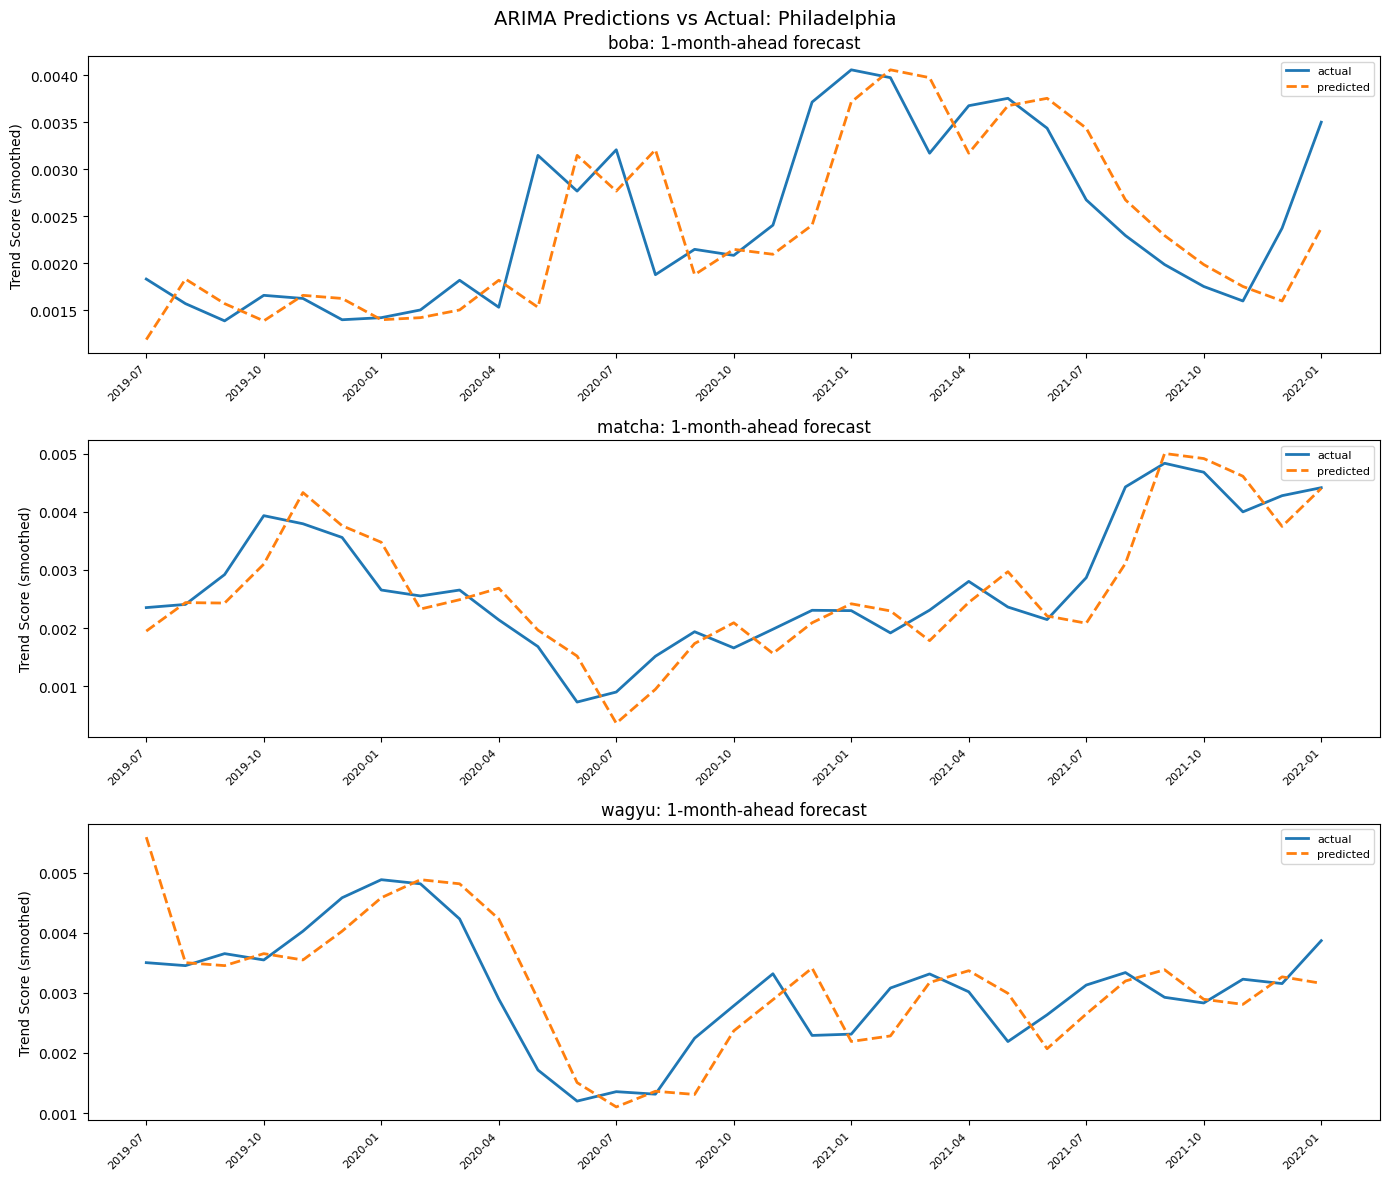

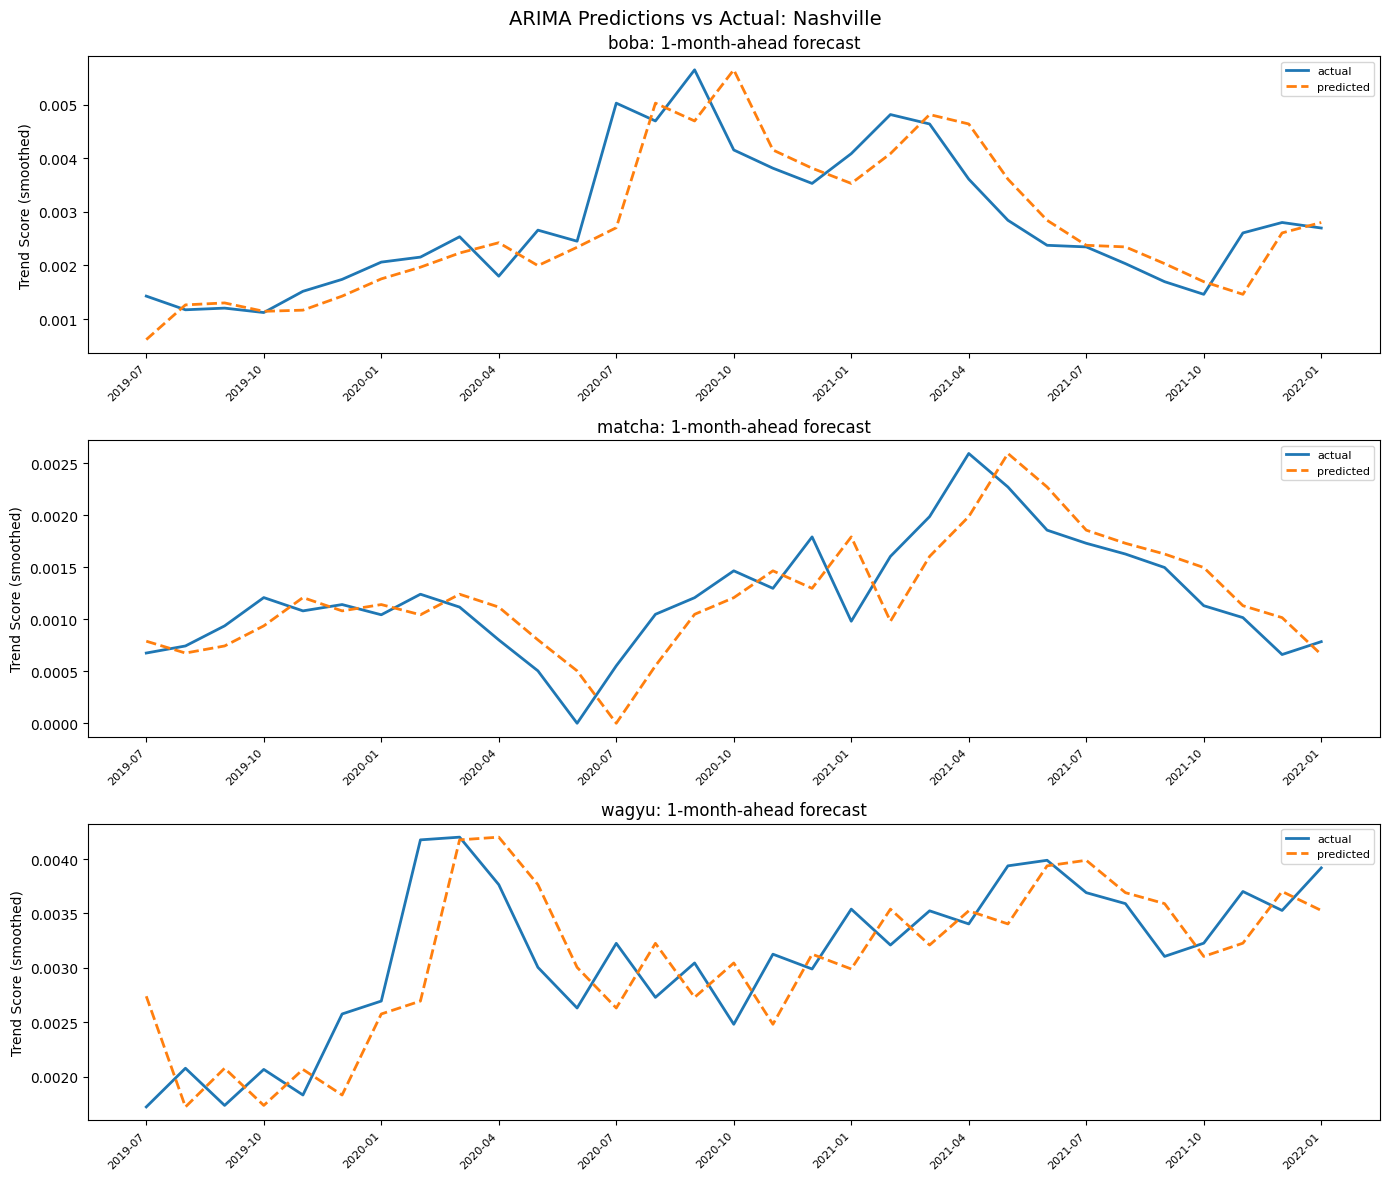

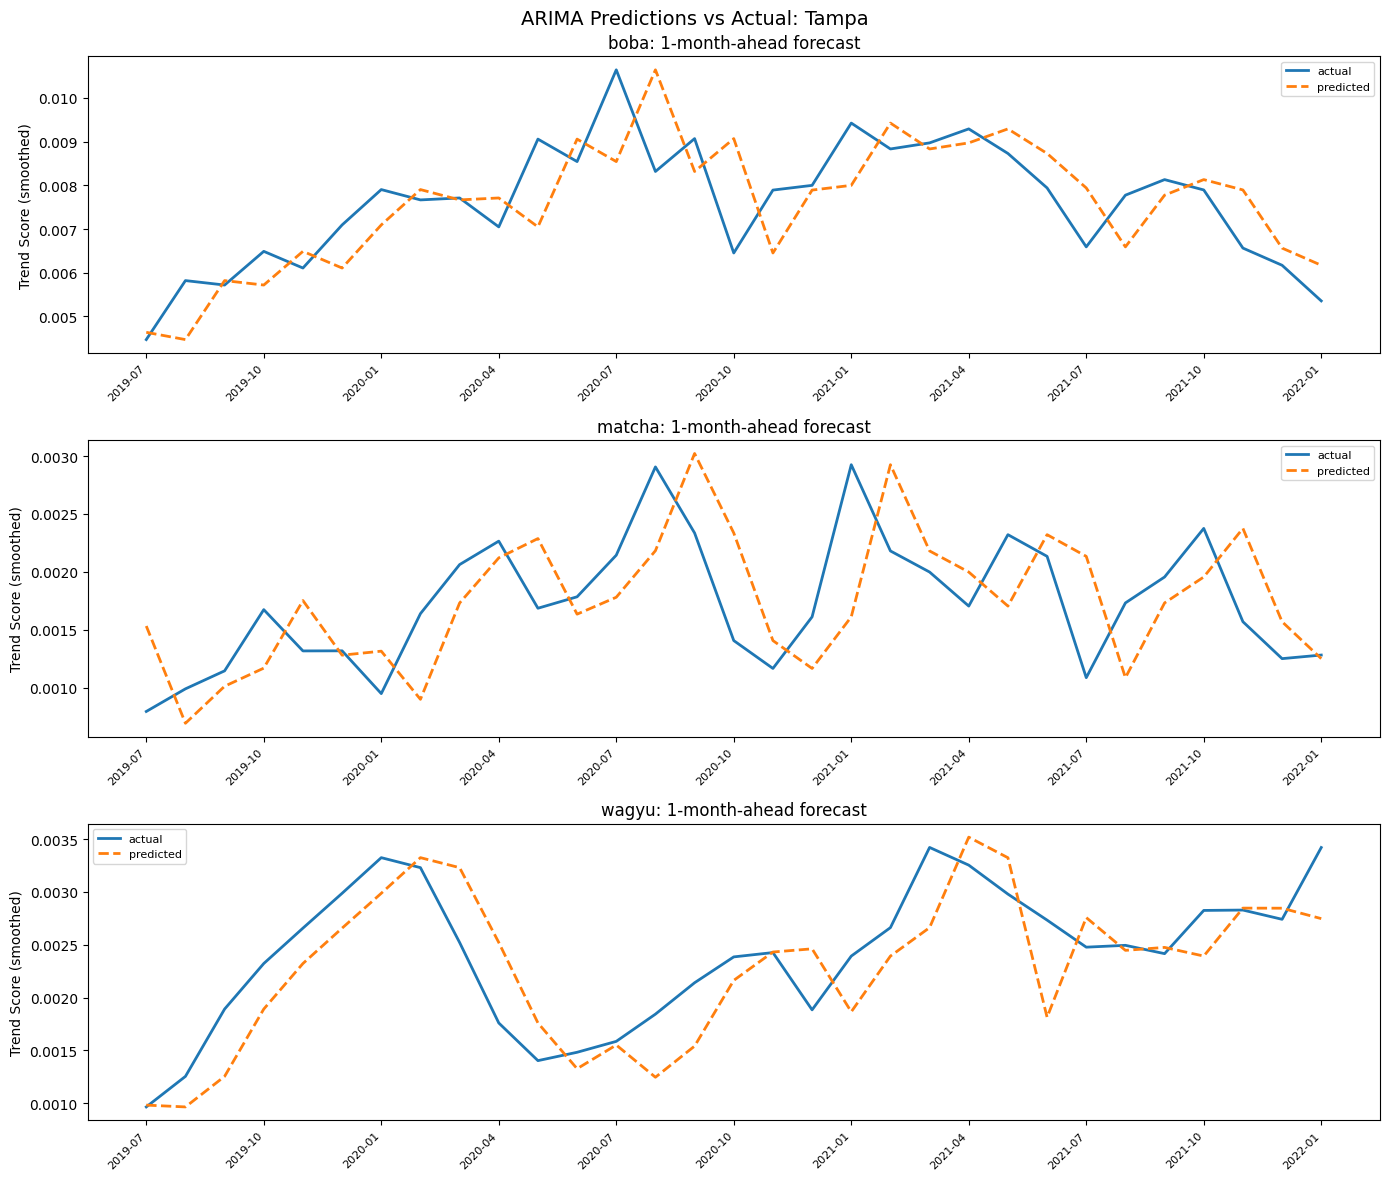

In [16]:
import matplotlib.pyplot as plt

keywords_to_plot = ["boba", "matcha", "wagyu"]
cities_to_plot = ["Philadelphia", "Nashville", "Tampa"]

for city_to_plot in cities_to_plot:
    fig, axes = plt.subplots(len(keywords_to_plot), 1, figsize=(14, 12), sharex=False)

    for ax, kw in zip(axes, keywords_to_plot):
        subset = results_df[
            (results_df["city"] == city_to_plot) &
            (results_df["keyword"] == kw) &
            (results_df["horizon"] == 1)
        ].sort_values("month").reset_index(drop=True)

        if subset.empty:
            ax.set_title(f"{kw} (no predictions)")
            continue

        ax.plot(range(len(subset)), subset["actual"], label="actual", linewidth=2)
        ax.plot(range(len(subset)), subset["predicted"], label="predicted", linewidth=2, linestyle="--")

        ax.set_title(f"{kw}: 1-month-ahead forecast")
        ax.set_ylabel("Trend Score (smoothed)")
        ax.legend(fontsize=8)

        n = len(subset)
        step = max(n // 8, 1)
        tick_positions = list(range(0, n, step))
        tick_labels = [subset["month"].iloc[i] for i in tick_positions]

        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=8)

    plt.suptitle(f"ARIMA Predictions vs Actual: {city_to_plot}", fontsize=14)
    plt.tight_layout()
    plt.show()